# ACV-LQN - OpenCV Basic - TH02

## Làm trơn ảnh (Smoothing) và phát hiện biên cạnh (Edge Detection)

**Nhóm:** Myopia

| MSHV | Họ tên |
|---|---|
| 25C11067 | Nguyễn Thái Thông |
| 25C11035 | Trần Hạ Khánh Duy |

## Mục lục

- [0. Chuẩn bị](#0-chuẩn-bị)
- [1. Làm trơn ảnh](#1-làm-trơn-ảnh)
- [2. Phát hiện biên cạnh](#2-phát-hiện-biên-cạnh)
- [3. Lưu kết quả](#3-lưu-kết-quả)
- [4. Kết luận](#4-kết-luận)

## 0. Chuẩn bị

Notebook này làm tiếp theo phương pháp TH01: dùng ảnh Lenna, cài đặt thủ công từng thuật toán, đối chiếu với hàm OpenCV, sau đó đo MSE, thời gian chạy và bộ nhớ đỉnh. Các đoạn code được comment kỹ để thấy rõ vai trò của từng bước xử lý.

In [2]:
# Chuẩn bị môi trường làm việc.
# Nếu chạy trên máy đã cài sẵn thư viện thì có thể bỏ qua cell này.
# Các dòng được comment lại để tránh cài lại mỗi khi chạy notebook.

# !pip install numpy>=1.24
# !pip install opencv-python>=4.8
# !pip install matplotlib>=3.7
# !pip install jupyter>=1.0

### 0.1. Tải ảnh Lenna giống TH01

In [ ]:
# Tạo thư mục data và outputs nếu chưa tồn tại.
# data: lưu ảnh đầu vào.
# outputs: lưu các hình minh chứng sau khi xử lý.
!mkdir -p data outputs

# Tải ảnh Lenna.
!wget -q -O data/Lenna.jpg http://www.ess.ic.kanagawa-it.ac.jp/std_img/colorimage/Lenna.jpg

# In thông báo để kiểm tra nhanh đường dẫn ảnh đã tải.
print("Đã tải ảnh: data/Lenna.jpg")

Đã tải ảnh: data/Lenna.jpg


### 0.2. Thiết lập thư viện và hàm tiện ích

Ảnh: data/Lenna.jpg
Kích thước ảnh màu: (150, 150, 3)
Kích thước ảnh xám: (150, 150)


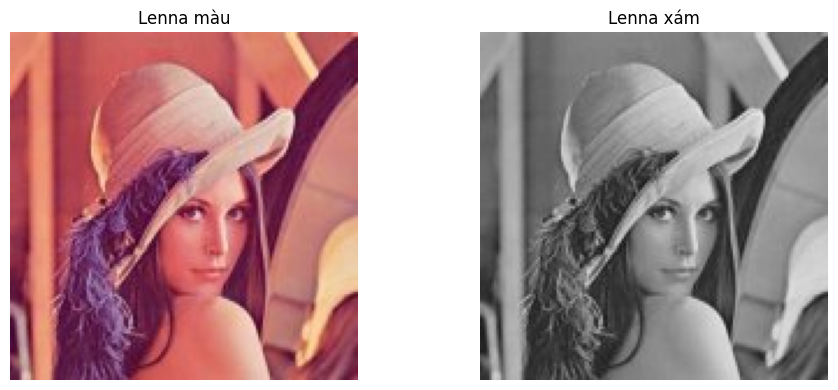

In [ ]:
from pathlib import Path
import time
import tracemalloc
import gc
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

# Khai báo các thư mục chính theo cấu trúc giống TH01.
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = Path("../doc/figures")

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_PATH = DATA_DIR / "Lenna.jpg"

# Đọc ảnh màu bằng OpenCV. OpenCV đọc ảnh theo thứ tự kênh BGR.
image_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)

# Kiểm tra ảnh có đọc được không. Nếu không đọc được thì dừng notebook để tránh lỗi phía sau.
if image_bgr is None:
    raise FileNotFoundError(f"Không đọc được ảnh: {IMAGE_PATH}. Hãy chạy lại cell tải ảnh Lenna.")

# Resize về 150x150 giống kích thước đã dùng ở TH01 để thuật toán thủ công chạy nhanh hơn.
# Việc giảm kích thước cũng giúp các vòng lặp Python không mất quá nhiều thời gian.
image_bgr = cv2.resize(image_bgr, (150, 150), interpolation=cv2.INTER_AREA)

# Chuyển ảnh màu BGR sang ảnh xám để dùng cho các thuật toán phát hiện biên.
gray_image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Ảnh: {IMAGE_PATH}")
print(f"Kích thước ảnh màu: {image_bgr.shape}")
print(f"Kích thước ảnh xám: {gray_image.shape}")

# Hàm chuyển BGR sang RGB để matplotlib hiển thị đúng màu.
def bgr_to_rgb(image):
    # OpenCV lưu thứ tự kênh là BGR, matplotlib mong đợi RGB.
    # [:, :, ::-1] đảo thứ tự kênh màu từ BGR thành RGB.
    return image[:, :, ::-1].copy()

# Hàm hiển thị nhiều ảnh trong cùng một figure.
def show_images(images, titles, cols=3, figsize=(14, 4), rgb_flags=None):
    # rgb_flags cho biết ảnh màu nào đã ở dạng RGB sẵn.
    if rgb_flags is None:
        rgb_flags = [False] * len(images)

    # Tính số hàng cần có dựa trên số ảnh và số cột.
    rows = int(np.ceil(len(images) / cols))

    # Tạo figure với kích thước truyền vào.
    plt.figure(figsize=figsize)

    # Lặp qua từng ảnh và tiêu đề tương ứng.
    for index, (img, title, is_rgb) in enumerate(zip(images, titles, rgb_flags), start=1):
        ax = plt.subplot(rows, cols, index)

        # Ảnh xám là ma trận 2 chiều nên dùng cmap='gray'.
        if img.ndim == 2:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            # Nếu ảnh chưa ở dạng RGB thì chuyển BGR -> RGB trước khi hiển thị.
            ax.imshow(img if is_rgb else cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Hàm tính Mean Squared Error giữa hai ảnh.
def mse(image_a, image_b):
    # Chuyển sang float32 để phép trừ không bị tràn số uint8.
    diff = image_a.astype(np.float32) - image_b.astype(np.float32)

    # MSE càng nhỏ thì hai ảnh càng giống nhau.
    return float(np.mean(diff ** 2))

# Hàm đo thời gian và bộ nhớ của một hàm xử lý ảnh.
def measure_time_memory(func, *args, repeat=3, **kwargs):
    times = []
    peaks_kb = []
    result = None

    # Chạy nhiều lần rồi lấy trung bình thời gian để giảm dao động.
    for _ in range(repeat):
        # Dọn rác trước khi đo để hạn chế ảnh hưởng từ lần chạy trước.
        gc.collect()

        # Bắt đầu theo dõi bộ nhớ cấp phát trong Python.
        tracemalloc.start()

        # Ghi nhận thời điểm bắt đầu.
        start = time.perf_counter()

        # Gọi hàm xử lý ảnh với tham số đã truyền.
        result = func(*args, **kwargs)

        # Tính thời gian chạy.
        elapsed = time.perf_counter() - start

        # Lấy bộ nhớ hiện tại và bộ nhớ đỉnh.
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        times.append(elapsed)
        peaks_kb.append(peak / 1024)

    # Trả về kết quả lần chạy cuối, thời gian trung bình và bộ nhớ đỉnh lớn nhất.
    return result, float(np.mean(times)), float(max(peaks_kb))

show_images([image_bgr, gray_image], ["Lenna màu", "Lenna xám"], cols=2, figsize=(10, 4))

## 1. Làm trơn ảnh

Làm trơn ảnh giúp giảm nhiễu, giảm chi tiết nhỏ và làm ảnh ổn định hơn trước khi phát hiện biên. Bài thực hành cài đặt ba bộ lọc: trung bình, Gaussian và median.

### 1.1. Bộ lọc trung bình

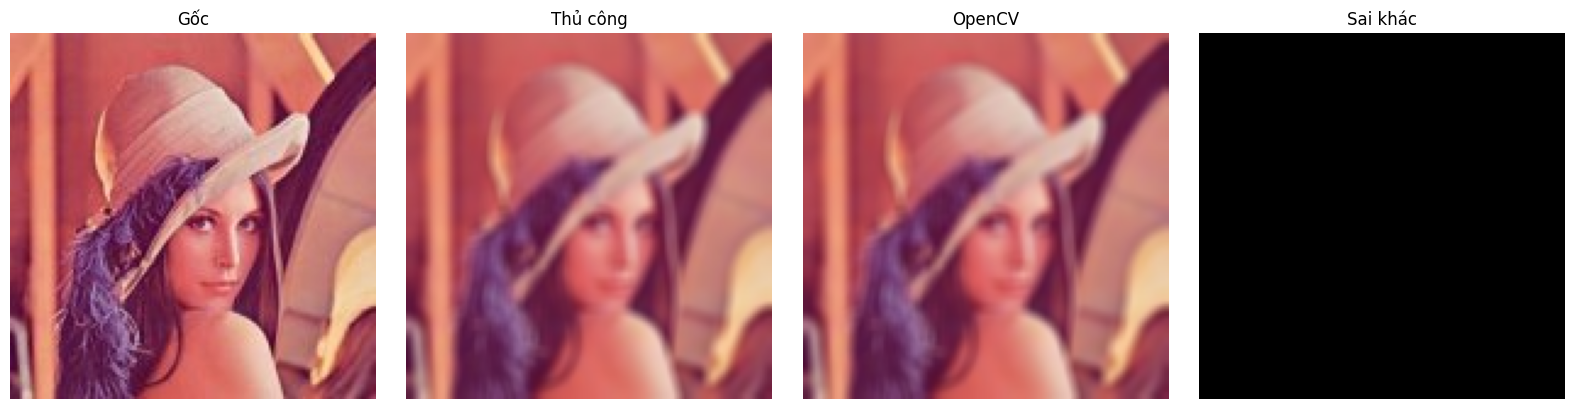

Sai số (MSE): 0.0000
Thủ công: 0.365850s | 1080.70KB
OpenCV: 0.001042s | 66.35KB


In [5]:
# Hàm padding ảnh bằng kiểu reflect.
# Padding cần thiết vì khi quét kernel ở sát biên ảnh, vùng lân cận có thể vượt ra ngoài ảnh gốc.
def pad_reflect(image, pad):
    if image.ndim == 2:
        # Ảnh xám: chỉ có chiều cao và chiều rộng.
        return np.pad(image, ((pad, pad), (pad, pad)), mode="reflect")

    # Ảnh màu: chỉ padding theo chiều cao/rộng, không padding chiều kênh màu.
    return np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")

# Cài đặt thủ công bộ lọc trung bình.
def mean_filter_manual(image, ksize=5):
    # ksize là kích thước cửa sổ lọc, ví dụ 5 nghĩa là vùng 5x5.
    pad = ksize // 2

    # Padding ảnh để xử lý được cả pixel nằm sát biên.
    padded = pad_reflect(image, pad).astype(np.float32)

    # Tạo ảnh kết quả cùng kích thước với ảnh đầu vào.
    output = np.zeros_like(image, dtype=np.float32)

    # Duyệt từng pixel trong ảnh.
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            # Lấy vùng lân cận ksize x ksize quanh pixel hiện tại.
            region = padded[y:y + ksize, x:x + ksize]

            # Giá trị mới là trung bình các pixel trong vùng lân cận.
            output[y, x] = np.mean(region, axis=(0, 1))

    # Làm tròn, chặn về [0,255], rồi chuyển về uint8 để thành ảnh hợp lệ.
    return np.clip(np.rint(output), 0, 255).astype(np.uint8)

# Cài đặt bằng OpenCV để đối chiếu.
def mean_filter_library(image, ksize=5):
    return cv2.blur(image, (ksize, ksize), borderType=cv2.BORDER_REFLECT_101)

# Đo hiệu năng và lấy ảnh kết quả.
mean_manual, t_mean_manual, m_mean_manual = measure_time_memory(mean_filter_manual, image_bgr, 5, repeat=3)
mean_library, t_mean_library, m_mean_library = measure_time_memory(mean_filter_library, image_bgr, 5, repeat=3)

# Ảnh sai khác giúp quan sát vị trí khác nhau giữa hai cách cài đặt.
mean_diff = cv2.absdiff(mean_manual, mean_library)

show_images([image_bgr, mean_manual, mean_library, mean_diff], ["Gốc", "Thủ công", "OpenCV", "Sai khác"], cols=4, figsize=(16, 4))
print(f"Sai số (MSE): {mse(mean_manual, mean_library):.4f}")
print(f"Thủ công: {t_mean_manual:.6f}s | {m_mean_manual:.2f}KB")
print(f"OpenCV: {t_mean_library:.6f}s | {m_mean_library:.2f}KB")

### 1.2. Bộ lọc Gaussian

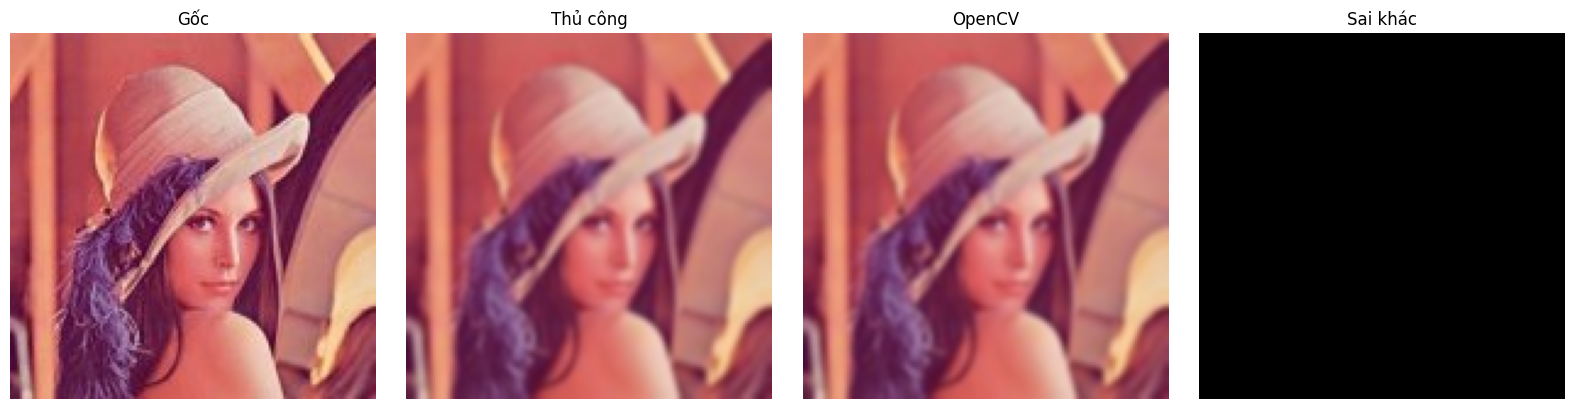

Sai số (MSE): 0.0053
Thủ công: 0.222884s | 802.26KB
OpenCV: 0.001628s | 66.35KB


In [6]:
# Tạo Gaussian kernel 2D.
def gaussian_kernel(ksize=5, sigma=1.2):
    # Tâm kernel nằm ở giữa ma trận.
    center = ksize // 2

    # Tạo lưới tọa độ x, y quanh tâm kernel.
    y, x = np.mgrid[-center:center + 1, -center:center + 1]

    # Công thức Gaussian 2D. Các điểm gần tâm có trọng số cao hơn.
    kernel = np.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))

    # Chuẩn hóa để tổng trọng số bằng 1, giúp ảnh không bị sáng/tối bất thường.
    kernel = kernel / np.sum(kernel)
    return kernel.astype(np.float32)

# Hàm tích chập trả về float, dùng cho các kernel có thể tạo giá trị âm như Sobel/Laplacian.
def convolve_float_manual(image, kernel):
    ksize = kernel.shape[0]
    pad = ksize // 2
    padded = pad_reflect(image, pad).astype(np.float32)

    # Output dạng float để giữ được giá trị âm/dương thật của phép tích chập.
    output = np.zeros(image.shape, dtype=np.float32)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            region = padded[y:y + ksize, x:x + ksize]

            if image.ndim == 2:
                # Ảnh xám: nhân từng phần tử vùng ảnh với kernel rồi cộng lại.
                output[y, x] = np.sum(region * kernel)
            else:
                # Ảnh màu: áp dụng cùng kernel cho từng kênh B, G, R.
                output[y, x] = np.sum(region * kernel[:, :, None], axis=(0, 1))

    return output

# Hàm tích chập trả về ảnh uint8, dùng cho các bộ lọc làm trơn.
def convolve_manual(image, kernel):
    response = convolve_float_manual(image, kernel)
    return np.clip(np.rint(response), 0, 255).astype(np.uint8)

# Cài đặt thủ công Gaussian filter.
def gaussian_filter_manual(image, ksize=5, sigma=1.2):
    kernel = gaussian_kernel(ksize, sigma)
    return convolve_manual(image, kernel)

# Cài đặt bằng OpenCV để đối chiếu.
def gaussian_filter_library(image, ksize=5, sigma=1.2):
    return cv2.GaussianBlur(image, (ksize, ksize), sigmaX=sigma, sigmaY=sigma, borderType=cv2.BORDER_REFLECT_101)

gaussian_manual, t_gaussian_manual, m_gaussian_manual = measure_time_memory(gaussian_filter_manual, image_bgr, 5, 1.2, repeat=3)
gaussian_library, t_gaussian_library, m_gaussian_library = measure_time_memory(gaussian_filter_library, image_bgr, 5, 1.2, repeat=3)
gaussian_diff = cv2.absdiff(gaussian_manual, gaussian_library)

show_images([image_bgr, gaussian_manual, gaussian_library, gaussian_diff], ["Gốc", "Thủ công", "OpenCV", "Sai khác"], cols=4, figsize=(16, 4))
print(f"Sai số (MSE): {mse(gaussian_manual, gaussian_library):.4f}")
print(f"Thủ công: {t_gaussian_manual:.6f}s | {m_gaussian_manual:.2f}KB")
print(f"OpenCV: {t_gaussian_library:.6f}s | {m_gaussian_library:.2f}KB")

### 1.3. Bộ lọc median

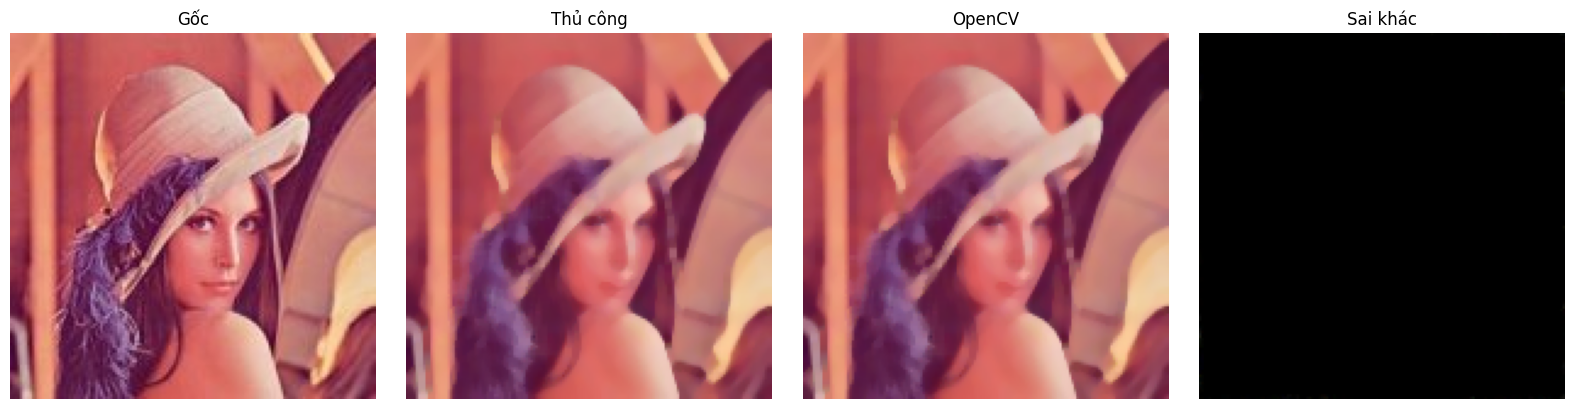

Sai số (MSE): 0.4045
Thủ công: 0.817596s | 216.54KB
OpenCV: 0.000487s | 66.18KB


In [ ]:
# Cài đặt median filter thủ công.
def median_filter_manual(image, ksize=5):
    pad = ksize // 2
    padded = pad_reflect(image, pad)
    output = np.zeros_like(image)

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            # Lấy vùng lân cận quanh pixel hiện tại.
            region = padded[y:y + ksize, x:x + ksize]

            # Lấy trung vị theo từng kênh
            output[y, x] = np.median(region, axis=(0, 1))

    return output.astype(np.uint8)

# Cài đặt bằng OpenCV để đối chiếu.
def median_filter_library(image, ksize=5):
    return cv2.medianBlur(image, ksize)

median_manual, t_median_manual, m_median_manual = measure_time_memory(median_filter_manual, image_bgr, 5, repeat=3)
median_library, t_median_library, m_median_library = measure_time_memory(median_filter_library, image_bgr, 5, repeat=3)
median_diff = cv2.absdiff(median_manual, median_library)

show_images([image_bgr, median_manual, median_library, median_diff], ["Gốc", "Thủ công", "OpenCV", "Sai khác"], cols=4, figsize=(16, 4))
print(f"Sai số (MSE): {mse(median_manual, median_library):.4f}")
print(f"Thủ công: {t_median_manual:.6f}s | {m_median_manual:.2f}KB")
print(f"OpenCV: {t_median_library:.6f}s | {m_median_library:.2f}KB")

## 2. Phát hiện biên cạnh

Phát hiện biên tìm các vùng có thay đổi cường độ sáng mạnh. Trước khi phát hiện biên, ảnh thường được làm trơn bằng Gaussian để giảm nhiễu.

### 2.1. Sobel

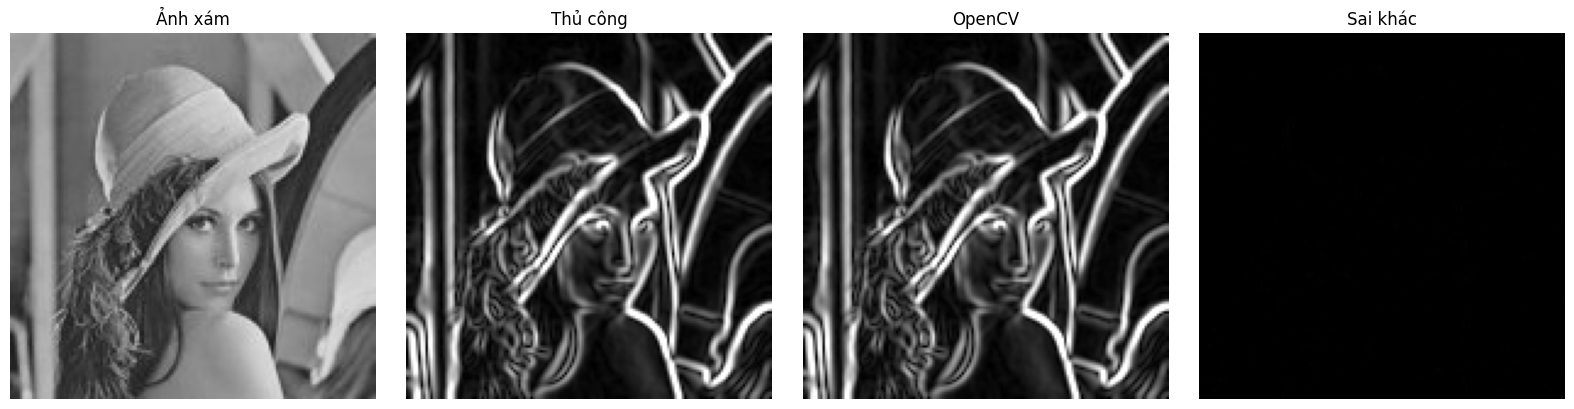

Sai số (MSE): 0.2713
Thủ công: 0.511674s | 470.94KB
OpenCV: 0.001183s | 397.21KB


In [ ]:
# Cài đặt Sobel thủ công
def sobel_manual(gray):
    # Giảm nhiễu trước khi tính gradient
    gray_smooth = gaussian_filter_manual(gray, 5, 1.0)

    # Kernel Sobel theo hướng x: nhấn mạnh biên dọc.
    gx_kernel = np.array([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]], dtype=np.float32)

    # Kernel Sobel theo hướng y: nhấn mạnh biên ngang.
    gy_kernel = np.array([[-1, -2, -1],
                          [ 0,  0,  0],
                          [ 1,  2,  1]], dtype=np.float32)

    # Giữ output float để không mất dấu âm/dương
    gx = convolve_float_manual(gray_smooth, gx_kernel)
    gy = convolve_float_manual(gray_smooth, gy_kernel)

    # Độ lớn gradient
    magnitude = np.sqrt(gx ** 2 + gy ** 2)

    return np.clip(magnitude, 0, 255).astype(np.uint8)

# Cài đặt Sobel bằng OpenCV.
def sobel_library(gray):
    gray_smooth = cv2.GaussianBlur(gray, (5, 5), 1.0, borderType=cv2.BORDER_REFLECT_101)
    gx = cv2.Sobel(gray_smooth, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_smooth, cv2.CV_32F, 0, 1, ksize=3)
    magnitude = cv2.magnitude(gx, gy)
    return np.clip(magnitude, 0, 255).astype(np.uint8)

sobel_manual_img, t_sobel_manual, m_sobel_manual = measure_time_memory(sobel_manual, gray_image, repeat=3)
sobel_library_img, t_sobel_library, m_sobel_library = measure_time_memory(sobel_library, gray_image, repeat=3)
sobel_diff = cv2.absdiff(sobel_manual_img, sobel_library_img)

show_images([gray_image, sobel_manual_img, sobel_library_img, sobel_diff], ["Ảnh xám", "Thủ công", "OpenCV", "Sai khác"], cols=4, figsize=(16, 4))
print(f"Sai số (MSE): {mse(sobel_manual_img, sobel_library_img):.4f}")
print(f"Thủ công: {t_sobel_manual:.6f}s | {m_sobel_manual:.2f}KB")
print(f"OpenCV: {t_sobel_library:.6f}s | {m_sobel_library:.2f}KB")

### 2.2. Laplacian

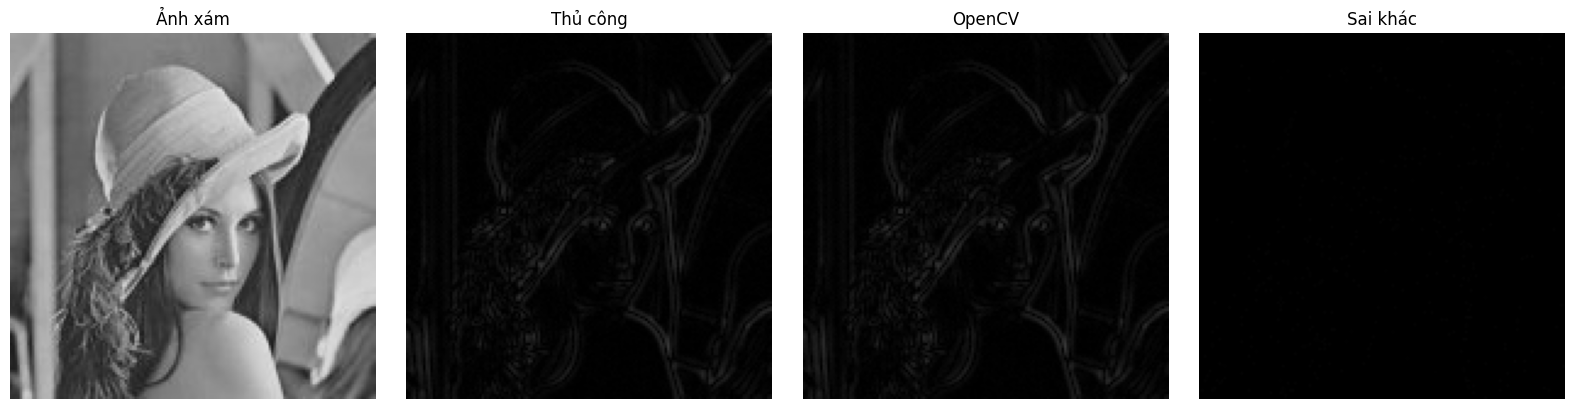

Sai số (MSE): 0.3692
Thủ công: 0.338727s | 293.96KB
OpenCV: 0.012127s | 88.54KB


In [ ]:
# Cài đặt Laplacian thủ công
def laplacian_manual(gray):
    # Laplacian nhạy nhiễu nên làm mượt trước
    gray_smooth = gaussian_filter_manual(gray, 5, 1.0)

    # Laplacian 4-neighborhood
    kernel = np.array([[0,  1, 0],
                       [1, -4, 1],
                       [0,  1, 0]], dtype=np.float32)

    # Dùng convolve float vì đáp ứng có thể âm
    response = convolve_float_manual(gray_smooth, kernel)

    # Lấy trị tuyệt đối để hiển thị độ mạnh biên
    return np.clip(np.abs(response), 0, 255).astype(np.uint8)

# Cài đặt Laplacian bằng OpenCV.
def laplacian_library(gray):
    gray_smooth = cv2.GaussianBlur(gray, (5, 5), 1.0, borderType=cv2.BORDER_REFLECT_101)
    response = cv2.Laplacian(gray_smooth, cv2.CV_16S, ksize=1)
    return cv2.convertScaleAbs(response)

laplacian_manual_img, t_laplacian_manual, m_laplacian_manual = measure_time_memory(laplacian_manual, gray_image, repeat=3)
laplacian_library_img, t_laplacian_library, m_laplacian_library = measure_time_memory(laplacian_library, gray_image, repeat=3)
laplacian_diff = cv2.absdiff(laplacian_manual_img, laplacian_library_img)

show_images([gray_image, laplacian_manual_img, laplacian_library_img, laplacian_diff], ["Ảnh xám", "Thủ công", "OpenCV", "Sai khác"], cols=4, figsize=(16, 4))
print(f"Sai số (MSE): {mse(laplacian_manual_img, laplacian_library_img):.4f}")
print(f"Thủ công: {t_laplacian_manual:.6f}s | {m_laplacian_manual:.2f}KB")
print(f"OpenCV: {t_laplacian_library:.6f}s | {m_laplacian_library:.2f}KB")

### 2.3. Laplace of Gaussian (LoG)

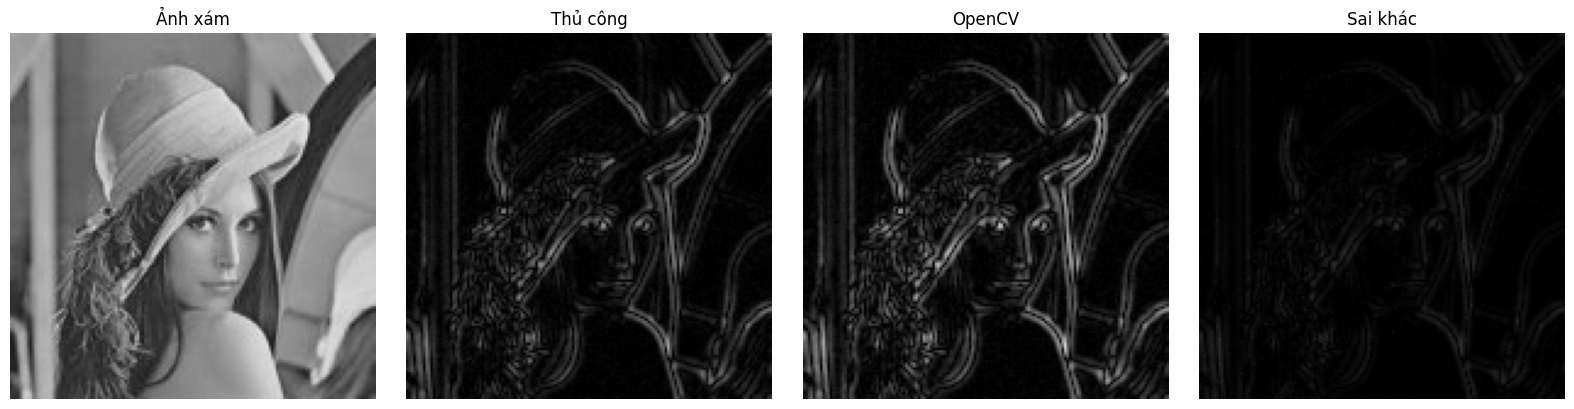

Sai số (MSE): 72.2126
Thủ công: 0.342847s | 293.61KB
OpenCV: 0.001922s | 88.54KB


In [10]:
# Cài đặt Laplace of Gaussian (LoG) thủ công.
def log_manual(gray):
    # LoG kết hợp làm trơn Gaussian và đạo hàm bậc hai Laplacian.
    # Bước Gaussian giúp giảm nhiễu trước khi tính Laplacian.
    gray_smooth = gaussian_filter_manual(gray, 5, 1.0)

    # Kernel Laplacian 8-neighborhood để bắt biến thiên theo cả hướng chéo.
    kernel = np.array([[1,  1, 1],
                       [1, -8, 1],
                       [1,  1, 1]], dtype=np.float32)

    response = convolve_float_manual(gray_smooth, kernel)
    return np.clip(np.abs(response), 0, 255).astype(np.uint8)

# Cài đặt LoG bằng OpenCV: GaussianBlur trước, sau đó Laplacian.
def log_library(gray):
    gray_smooth = cv2.GaussianBlur(gray, (5, 5), 1.0, borderType=cv2.BORDER_REFLECT_101)
    response = cv2.Laplacian(gray_smooth, cv2.CV_16S, ksize=3)
    return cv2.convertScaleAbs(response)

log_manual_img, t_log_manual, m_log_manual = measure_time_memory(log_manual, gray_image, repeat=3)
log_library_img, t_log_library, m_log_library = measure_time_memory(log_library, gray_image, repeat=3)
log_diff = cv2.absdiff(log_manual_img, log_library_img)

show_images([gray_image, log_manual_img, log_library_img, log_diff], ["Ảnh xám", "Thủ công", "OpenCV", "Sai khác"], cols=4, figsize=(16, 4))
print(f"Sai số (MSE): {mse(log_manual_img, log_library_img):.4f}")
print(f"Thủ công: {t_log_manual:.6f}s | {m_log_manual:.2f}KB")
print(f"OpenCV: {t_log_library:.6f}s | {m_log_library:.2f}KB")


### 2.4. Canny

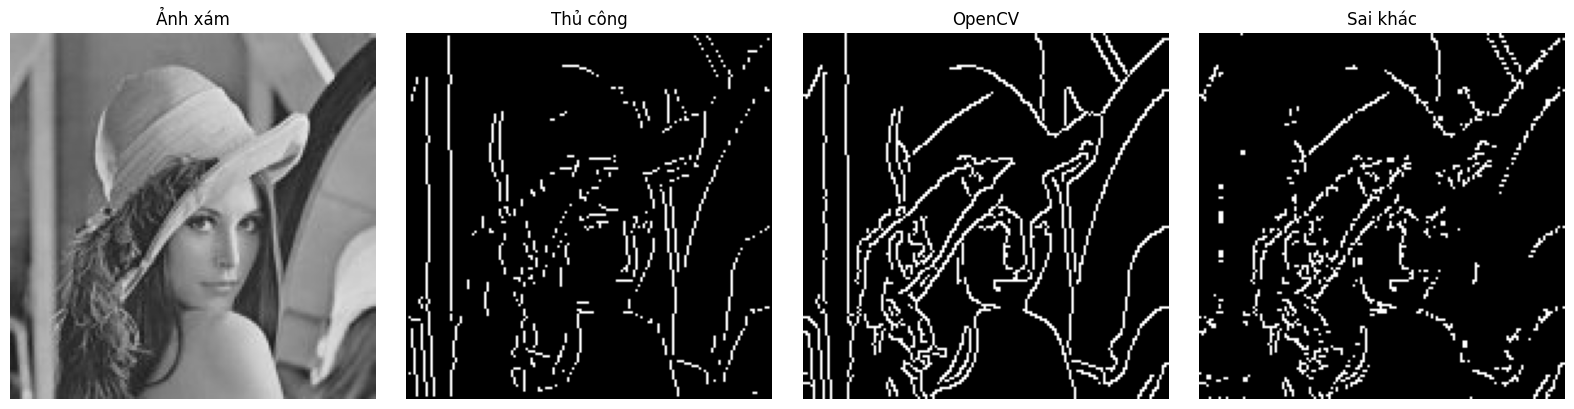

Sai số (MSE): 4629.7798
Thủ công: 0.560139s | 563.33KB
OpenCV: 0.003300s | 44.40KB


In [11]:
# Non-maximum suppression làm mảnh biên.
# Chỉ giữ pixel nếu nó là cực đại cục bộ theo hướng gradient.
def non_maximum_suppression(magnitude, angle):
    h, w = magnitude.shape
    output = np.zeros((h, w), dtype=np.float32)

    # Đưa góc gradient về khoảng [0, 180).
    angle = angle % 180

    # Bỏ qua viền ngoài để tránh truy cập ra ngoài ảnh.
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            direction = angle[y, x]
            current = magnitude[y, x]

            # Chọn hai pixel lân cận để so sánh theo hướng gradient gần nhất.
            if (0 <= direction < 22.5) or (157.5 <= direction <= 180):
                q, r = magnitude[y, x + 1], magnitude[y, x - 1]
            elif 22.5 <= direction < 67.5:
                q, r = magnitude[y + 1, x - 1], magnitude[y - 1, x + 1]
            elif 67.5 <= direction < 112.5:
                q, r = magnitude[y + 1, x], magnitude[y - 1, x]
            else:
                q, r = magnitude[y - 1, x - 1], magnitude[y + 1, x + 1]

            # Nếu pixel hiện tại mạnh nhất theo hướng gradient thì giữ lại.
            if current >= q and current >= r:
                output[y, x] = current

    return output

# Hysteresis threshold nối các biên yếu nếu chúng kề với biên mạnh.
def hysteresis_threshold(image, low, high):
    strong = 255
    weak = 75

    # Khởi tạo ảnh kết quả gồm ba trạng thái: 0, weak, strong.
    result = np.zeros_like(image, dtype=np.uint8)
    result[image >= high] = strong
    result[(image >= low) & (image < high)] = weak

    h, w = image.shape

    # Duyệt các pixel weak. Nếu kề strong thì nâng thành strong, ngược lại loại bỏ.
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            if result[y, x] == weak:
                neighborhood = result[y - 1:y + 2, x - 1:x + 2]
                if np.any(neighborhood == strong):
                    result[y, x] = strong
                else:
                    result[y, x] = 0

    # Chỉ giữ biên mạnh cuối cùng.
    result[result != strong] = 0
    return result

# Cài đặt Canny thủ công theo các bước chính.
def canny_manual(gray, low_threshold=60, high_threshold=130):
    # Bước 1: làm trơn Gaussian.
    smooth = gaussian_filter_manual(gray, 5, 1.0)

    # Bước 2: tính gradient bằng Sobel.
    gx_kernel = np.array([[-1, 0, 1],
                          [-2, 0, 2],
                          [-1, 0, 1]], dtype=np.float32)
    gy_kernel = np.array([[-1, -2, -1],
                          [ 0,  0,  0],
                          [ 1,  2,  1]], dtype=np.float32)
    gx = convolve_float_manual(smooth, gx_kernel)
    gy = convolve_float_manual(smooth, gy_kernel)

    # Bước 3: tính độ lớn và hướng gradient.
    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    angle = np.rad2deg(np.arctan2(gy, gx))

    # Bước 4: làm mảnh biên.
    suppressed = non_maximum_suppression(magnitude, angle)

    # Bước 5: ngưỡng kép và nối biên.
    return hysteresis_threshold(suppressed, low_threshold, high_threshold)

# Cài đặt Canny bằng OpenCV.
def canny_library(gray, low_threshold=60, high_threshold=130):
    smooth = cv2.GaussianBlur(gray, (5, 5), 1.0, borderType=cv2.BORDER_REFLECT_101)
    return cv2.Canny(smooth, low_threshold, high_threshold)

# Canny thủ công dùng vòng lặp nhiều nên chỉ repeat=1 để tiết kiệm thời gian.
canny_manual_img, t_canny_manual, m_canny_manual = measure_time_memory(canny_manual, gray_image, 60, 130, repeat=1)
canny_library_img, t_canny_library, m_canny_library = measure_time_memory(canny_library, gray_image, 60, 130, repeat=3)
canny_diff = cv2.absdiff(canny_manual_img, canny_library_img)

show_images([gray_image, canny_manual_img, canny_library_img, canny_diff], ["Ảnh xám", "Thủ công", "OpenCV", "Sai khác"], cols=4, figsize=(16, 4))
print(f"Sai số (MSE): {mse(canny_manual_img, canny_library_img):.4f}")
print(f"Thủ công: {t_canny_manual:.6f}s | {m_canny_manual:.2f}KB")
print(f"OpenCV: {t_canny_library:.6f}s | {m_canny_library:.2f}KB")

## 3. Lưu kết quả

Cell dưới đây lưu các hình tổng hợp vào `source/outputs` và `doc/figures`, đồng thời tạo file `result.txt` để dùng khi viết báo cáo.

In [12]:
# Hàm lưu panel hình giống cách trình bày ở TH01.
def save_panel_figure(name, images, titles, rgb_flags=None, cols=4, figsize=(16, 4)):
    if rgb_flags is None:
        rgb_flags = [False] * len(images)

    rows = int(np.ceil(len(images) / cols))
    fig = plt.figure(figsize=figsize)

    for index, (img, title, is_rgb) in enumerate(zip(images, titles, rgb_flags), start=1):
        ax = plt.subplot(rows, cols, index)

        if img.ndim == 2:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        else:
            ax.imshow(img if is_rgb else cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    # Lưu cùng lúc vào outputs của notebook và figures của báo cáo.
    for folder in (OUTPUT_DIR, FIGURE_DIR):
        folder.mkdir(parents=True, exist_ok=True)
        fig.savefig(folder / name, bbox_inches="tight", dpi=150)

    plt.close(fig)

# Lưu hình minh chứng cho từng phần.
save_panel_figure("01_lenna.png", [image_bgr, gray_image], ["Lenna màu", "Lenna xám"], cols=2, figsize=(10, 4))
save_panel_figure("02_mean_filter.png", [image_bgr, mean_manual, mean_library, mean_diff], ["Gốc", "Thủ công", "OpenCV", "Sai khác"])
save_panel_figure("03_gaussian_filter.png", [image_bgr, gaussian_manual, gaussian_library, gaussian_diff], ["Gốc", "Thủ công", "OpenCV", "Sai khác"])
save_panel_figure("04_median_filter.png", [image_bgr, median_manual, median_library, median_diff], ["Gốc", "Thủ công", "OpenCV", "Sai khác"])
save_panel_figure("05_sobel.png", [gray_image, sobel_manual_img, sobel_library_img, sobel_diff], ["Ảnh xám", "Thủ công", "OpenCV", "Sai khác"])
save_panel_figure("06_laplacian.png", [gray_image, laplacian_manual_img, laplacian_library_img, laplacian_diff], ["Ảnh xám", "Thủ công", "OpenCV", "Sai khác"])
save_panel_figure("07_log.png", [gray_image, log_manual_img, log_library_img, log_diff], ["Ảnh xám", "Thủ công", "OpenCV", "Sai khác"])
save_panel_figure("08_canny.png", [gray_image, canny_manual_img, canny_library_img, canny_diff], ["Ảnh xám", "Thủ công", "OpenCV", "Sai khác"])

# Gom kết quả để in thành bảng tóm tắt dạng text.
results = [
    ("Mean filter", mean_manual, mean_library, t_mean_manual, m_mean_manual, t_mean_library, m_mean_library),
    ("Gaussian filter", gaussian_manual, gaussian_library, t_gaussian_manual, m_gaussian_manual, t_gaussian_library, m_gaussian_library),
    ("Median filter", median_manual, median_library, t_median_manual, m_median_manual, t_median_library, m_median_library),
    ("Sobel", sobel_manual_img, sobel_library_img, t_sobel_manual, m_sobel_manual, t_sobel_library, m_sobel_library),
    ("Laplacian", laplacian_manual_img, laplacian_library_img, t_laplacian_manual, m_laplacian_manual, t_laplacian_library, m_laplacian_library),
    ("Laplace of Gaussian (LoG)", log_manual_img, log_library_img, t_log_manual, m_log_manual, t_log_library, m_log_library),
    ("Canny", canny_manual_img, canny_library_img, t_canny_manual, m_canny_manual, t_canny_library, m_canny_library),
]

summary_lines = []
for index, (name, manual_img, library_img, t_manual, mem_manual, t_library, mem_library) in enumerate(results, start=1):
    summary_lines.extend([
        f"{index}. {name}",
        f"   Sai số (MSE): {mse(manual_img, library_img):.4f}",
        f"   Thủ công: {t_manual:.6f}s | {mem_manual:.2f}KB",
        f"   OpenCV: {t_library:.6f}s | {mem_library:.2f}KB",
        "",
    ])

summary_text = "\n".join(summary_lines).strip() + "\n"

# Ghi result.txt vào cả hai thư mục để tiện nộp bài và viết báo cáo.
for folder in (OUTPUT_DIR, FIGURE_DIR):
    (folder / "result.txt").write_text(summary_text, encoding="utf-8")

print(summary_text)

# In danh sách hình đã lưu trong outputs.
for path in sorted(OUTPUT_DIR.glob("*.png")):
    print(path)

1. Mean filter
   Sai số (MSE): 0.0000
   Thủ công: 0.365850s | 1080.70KB
   OpenCV: 0.001042s | 66.35KB

2. Gaussian filter
   Sai số (MSE): 0.0053
   Thủ công: 0.222884s | 802.26KB
   OpenCV: 0.001628s | 66.35KB

3. Median filter
   Sai số (MSE): 0.4045
   Thủ công: 0.817596s | 216.54KB
   OpenCV: 0.000487s | 66.18KB

4. Sobel
   Sai số (MSE): 0.2713
   Thủ công: 0.511674s | 470.94KB
   OpenCV: 0.001183s | 397.21KB

5. Laplacian
   Sai số (MSE): 0.3692
   Thủ công: 0.338727s | 293.96KB
   OpenCV: 0.012127s | 88.54KB

6. Laplace of Gaussian (LoG)
   Sai số (MSE): 72.2126
   Thủ công: 0.342847s | 293.61KB
   OpenCV: 0.001922s | 88.54KB

7. Canny
   Sai số (MSE): 4629.7798
   Thủ công: 0.560139s | 563.33KB
   OpenCV: 0.003300s | 44.40KB

outputs/01_lenna.png
outputs/02_mean_filter.png
outputs/03_gaussian_filter.png
outputs/04_median_filter.png
outputs/05_sobel.png
outputs/06_laplacian.png
outputs/07_log.png
outputs/08_canny.png


## 4. Kết luận

Bài thực hành đã cài đặt và đối chiếu các phép làm trơn ảnh gồm mean filter, Gaussian filter và median filter. Mean filter làm mờ đều toàn vùng lân cận, Gaussian filter ưu tiên các điểm gần tâm nên giữ cấu trúc ảnh tự nhiên hơn, còn median filter phù hợp để khử nhiễu dạng điểm.

Ở phần phát hiện biên, Sobel dùng gradient bậc một để tìm thay đổi cường độ sáng theo hai hướng, Laplacian dùng đạo hàm bậc hai nên nhạy với vùng thay đổi mạnh, Laplace of Gaussian (LoG) làm trơn Gaussian trước khi tính Laplacian để giảm nhiễu, còn Canny kết hợp làm trơn, gradient, non-maximum suppression và hysteresis threshold để tạo biên mảnh hơn. OpenCV cho tốc độ tốt hơn rõ rệt, còn cài đặt thủ công giúp hiểu bản chất thuật toán.